# Support Vector Machines — Clasificación de Tumores Mamarios
### Seminario de Machine Learning · Inteligencia Artificial · UNSA EPIS
---
> **Dataset:** Wisconsin Breast Cancer · **Algoritmo:** SVM con kernel RBF  
> **Objetivo:** Clasificar tumores como malignos o benignos a partir de  
> 30 características extraídas de biopsias digitalizadas.

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.metrics.pairwise import rbf_kernel
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Librerías cargadas.")

Librerías cargadas.


## 1. Carga de Datos

El dataset fue creado por el Dr. William H. Wolberg (U. de Wisconsin)
a partir de biopsias de masa mamaria analizadas con **Fine Needle
Aspiration (FNA)**. Cada muestra tiene **30 features numéricas** que
describen el núcleo celular: radio, textura, perímetro, área, suavidad,
compacidad, concavidad y simetría — en valor medio, error estándar y
valor extremo.

| Propiedad | Valor |
|-----------|-------|
| Muestras  | 569   |
| Features  | 30    |
| Clases    | Maligno (0) · Benigno (1) |

In [5]:
data = load_breast_cancer()
X, y = data.data, data.target

print("=" * 50)
print("INFORMACIÓN DEL DATASET")
print("=" * 50)
print(f"Muestras   : {X.shape[0]}")
print(f"Features   : {X.shape[1]}")
print(f"Maligno(0) : {(y == 0).sum()}  ({(y==0).mean()*100:.1f}%)")
print(f"Benigno(1) : {(y == 1).sum()}  ({(y==1).mean()*100:.1f}%)")
print()
print(f"{'Feature':40s} {'Media':>8} {'Std':>8}")
print("-" * 58)
for i in range(len(data.feature_names)):
    print(f"{data.feature_names[i]:40s} {X[:,i].mean():>8.3f} {X[:,i].std():>8.3f}")


INFORMACIÓN DEL DATASET
Muestras   : 569
Features   : 30
Maligno(0) : 212  (37.3%)
Benigno(1) : 357  (62.7%)

Feature                                     Media      Std
----------------------------------------------------------
mean radius                                14.127    3.521
mean texture                               19.290    4.297
mean perimeter                             91.969   24.278
mean area                                 654.889  351.605
mean smoothness                             0.096    0.014
mean compactness                            0.104    0.053
mean concavity                              0.089    0.080
mean concave points                         0.049    0.039
mean symmetry                               0.181    0.027
mean fractal dimension                      0.063    0.007
radius error                                0.405    0.277
texture error                               1.217    0.551
perimeter error                             2.866    2.020
area 

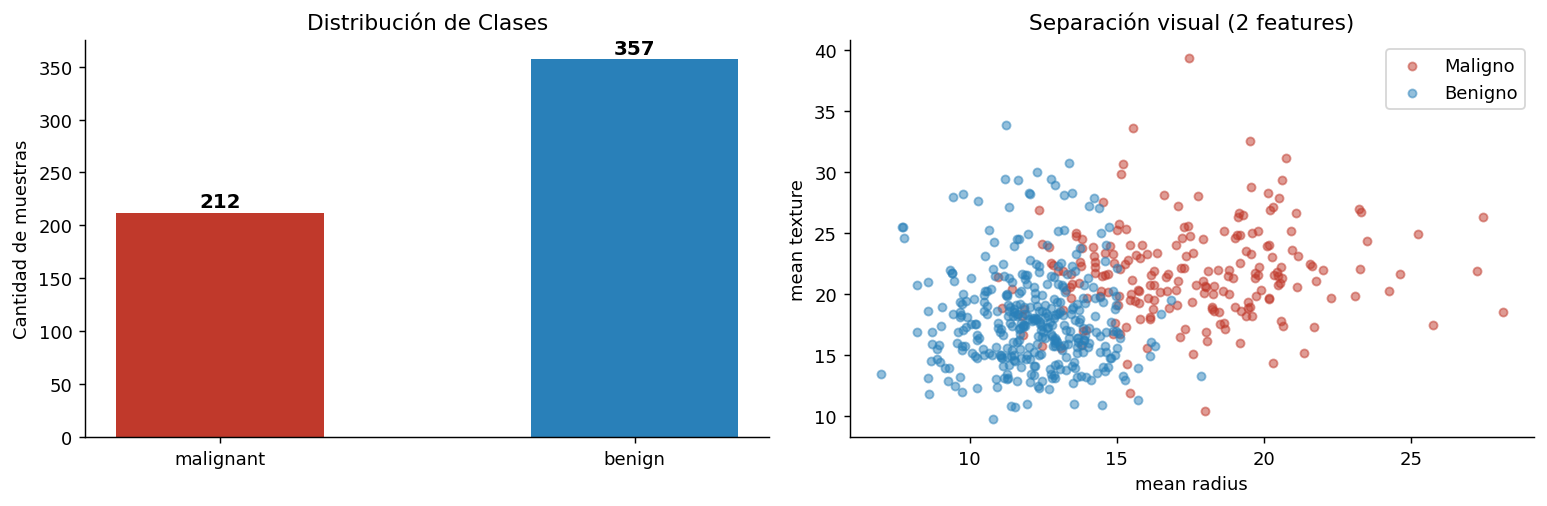

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de clases
counts = [(y == 0).sum(), (y == 1).sum()]
bars = axes[0].bar(data.target_names, counts,
                   color=['#c0392b', '#2980b9'], width=0.5)
axes[0].set_title("Distribución de Clases", fontsize=12)
axes[0].set_ylabel("Cantidad de muestras")
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5, str(count),
                 ha='center', fontsize=11, fontweight='bold')

# Comparación de 2 features entre clases
feat_a, feat_b = 0, 1   # mean radius vs mean texture
malignos = X[y == 0]
benignos = X[y == 1]
axes[1].scatter(malignos[:, feat_a], malignos[:, feat_b],
                c='#c0392b', alpha=0.5, s=20, label='Maligno')
axes[1].scatter(benignos[:, feat_a], benignos[:, feat_b],
                c='#2980b9', alpha=0.5, s=20, label='Benigno')
axes[1].set_xlabel(data.feature_names[feat_a])
axes[1].set_ylabel(data.feature_names[feat_b])
axes[1].set_title("Separación visual (2 features)", fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()


## 2. División Train / Test

Dividimos el dataset en 80% para entrenamiento y 20% para prueba.
El parámetro `stratify=y` garantiza que la proporción de clases
(maligno/benigno) sea la misma en ambos conjuntos — si no lo hacemos,
por azar podría quedar un split con muchos más malignos en test que en
train, y las métricas serían engañosas.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Train : {X_train.shape[0]} muestras "
      f"(maligno: {(y_train==0).sum()}, benigno: {(y_train==1).sum()})")
print(f"Test  : {X_test.shape[0]} muestras "
      f"(maligno: {(y_test==0).sum()}, benigno: {(y_test==1).sum()})")

Train : 455 muestras (maligno: 170, benigno: 285)
Test  : 114 muestras (maligno: 42, benigno: 72)


## 3. Preprocesamiento: StandardScaler

SVM calcula distancias entre puntos para construir la frontera.
El kernel RBF usa específicamente:

$$\|\mathbf{x}_i - \mathbf{x}_j\|^2 = \sum_{k=1}^{d}(x_{ik} - x_{jk})^2$$

Si una feature varía entre 0 y 2500 (área) y otra entre 0.05 y 0.16
(suavidad), la primera domina el cálculo por pura escala, no por
importancia real. `StandardScaler` lleva cada feature a media 0 y
desviación estándar 1:

$$z = \frac{x - \mu}{\sigma}$$

**Regla crítica:** el escalador aprende $\mu$ y $\sigma$ **solo del train**
y los aplica al test sin recalcular. Si se hace `fit_transform` también
en test, se filtra información del futuro al modelo (*data leakage*).

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # aprende μ y σ del train, aplica
X_test  = scaler.transform(X_test)       # aplica los mismos μ y σ, sin reaprender

print(f"{'Feature':40s} {'μ antes':>9} {'μ después':>11} {'σ antes':>9} {'σ después':>11}")
print("-" * 82)
for i in range(5):
    # los valores "antes" los recuperamos desde el scaler
    print(f"{data.feature_names[i]:40s} "
          f"{scaler.mean_[i]:>9.3f} "
          f"{X_train[:,i].mean():>11.6f} "
          f"{scaler.scale_[i]:>9.3f} "
          f"{X_train[:,i].std():>11.6f}")

Feature                                    μ antes   μ después   σ antes   σ después
----------------------------------------------------------------------------------
mean radius                                 14.067   -0.000000     3.496    1.000000
mean texture                                19.247    0.000000     4.400    1.000000
mean perimeter                              91.557   -0.000000    24.123    1.000000
mean area                                  648.541    0.000000   344.565    1.000000
mean smoothness                              0.096    0.000000     0.013    1.000000


## 4. Entrenamiento: SVC con Kernel RBF

### El problema que SVM resuelve

SVM busca el hiperplano $\mathbf{w}^\top \mathbf{x} + b = 0$ que
maximiza el **margen** entre las dos clases. Con datos que no son
perfectamente separables (*soft margin*), el problema es:

$$\min_{\mathbf{w}, b, \xi} \quad \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_{i=1}^{n}\xi_i \quad \text{s.a.} \quad y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1 - \xi_i$$

Donde $C$ controla el balance entre margen amplio y errores permitidos.

### Por qué se usa el problema dual

Aplicando multiplicadores de Lagrange $\alpha_i$, el problema
se transforma y los datos aparecen solo como **productos punto**
$\mathbf{x}_i^\top \mathbf{x}_j$. Esto permite reemplazarlos
con una función kernel sin calcular la transformación explícita:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \exp\left(-\gamma\|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$$

### Cómo se resuelve: algoritmo SMO

`SVC` usa internamente **libsvm**, una implementación del algoritmo
**SMO (Sequential Minimal Optimization)**. En vez de resolver el
sistema de $n$ variables $\alpha_i$ de una sola vez, SMO selecciona
en cada paso el par $(\alpha_i, \alpha_j)$ que más viola las
condiciones de optimalidad y lo resuelve analíticamente, repitiendo
hasta convergencia.

Al terminar, los **vectores de soporte** son las muestras con
$\alpha_i > 0$ — el resto del dataset no influye en la frontera.

In [11]:
model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model.fit(X_train, y_train)

gamma_val = 1 / (X_train.shape[1] * X_train.var())

print("=" * 50)
print("MODELO ENTRENADO")
print("=" * 50)
print(f"Kernel            : RBF")
print(f"C                 : {model.C}")
print(f"gamma='scale' →   : {gamma_val:.6f}")
print()
print(f"Muestras train           : {X_train.shape[0]}")
print(f"Vectores de soporte      : {sum(model.n_support_)} "
      f"({sum(model.n_support_)/X_train.shape[0]*100:.1f}% del train)")
print(f"  Clase maligno (0)      : {model.n_support_[0]}")
print(f"  Clase benigno (1)      : {model.n_support_[1]}")
print()
print("El modelo descartó el resto del dataset.")
print("Solo estos vectores sostienen la frontera de decisión.")

MODELO ENTRENADO
Kernel            : RBF
C                 : 1.0
gamma='scale' →   : 0.033333

Muestras train           : 455
Vectores de soporte      : 97 (21.3% del train)
  Clase maligno (0)      : 51
  Clase benigno (1)      : 46

El modelo descartó el resto del dataset.
Solo estos vectores sostienen la frontera de decisión.


## 5. Verificación Manual del Kernel RBF

Podemos calcular $K(\mathbf{x}_i, \mathbf{x}_j)$ a mano entre dos
vectores de soporte y verificar que coincide con sklearn.
Esto confirma que entendemos lo que el modelo calcula internamente.

El valor resultante está en $[0, 1]$: valores cercanos a 1 indican
alta similitud en el espacio transformado; cercanos a 0, poca influencia
mutua en la frontera.

In [13]:
sv = model.support_vectors_
x_i, x_j = sv[0], sv[1]

dist_sq  = np.sum((x_i - x_j) ** 2)
k_manual = np.exp(-gamma_val * dist_sq)
k_skl    = rbf_kernel(x_i.reshape(1,-1), x_j.reshape(1,-1), gamma=gamma_val)[0,0]

print(f"Distancia euclidiana²     : {dist_sq:.6f}")
print(f"γ utilizado               : {gamma_val:.6f}")
print(f"K(x_i, x_j) manual       : {k_manual:.8f}")
print(f"K(x_i, x_j) sklearn      : {k_skl:.8f}")
print(f"Diferencia numérica       : {abs(k_manual - k_skl):.2e}")
print()
similitud = "alta" if k_manual > 0.5 else "baja"
print(f"→ Similitud entre estos dos vectores de soporte: {similitud}")
print(f"  (K=1.0 = idénticos, K≈0 = sin influencia mutua)")

Distancia euclidiana²     : 25.595991
γ utilizado               : 0.033333
K(x_i, x_j) manual       : 0.42604952
K(x_i, x_j) sklearn      : 0.42604952
Diferencia numérica       : 0.00e+00

→ Similitud entre estos dos vectores de soporte: baja
  (K=1.0 = idénticos, K≈0 = sin influencia mutua)


## 6. Predicción

Para cada muestra nueva $\mathbf{x}$, el modelo evalúa:

$$f(\mathbf{x}) = \text{sign}\!\left(\sum_{i \in SV} \alpha_i \, y_i \, K(\mathbf{x}_i, \mathbf{x}) + b\right)$$

Solo los vectores de soporte ($\alpha_i > 0$) contribuyen a esta suma.

### Métricas

| Métrica | Fórmula | Relevancia aquí |
|---------|---------|-----------------|
| Accuracy | $(TP+TN)\ /\ \text{total}$ | General, puede ser engañosa |
| Precision | $TP\ /\ (TP+FP)$ | ¿Cuántos "maligno" eran reales? |
| **Recall** | $TP\ /\ (TP+FN)$ | **¿Cuántos malignos detectó?** — La más importante |
| F1 | $2PR\ /\ (P+R)$ | Balance entre ambas |

Un **Falso Negativo** aquí = tumor maligno diagnosticado como benigno
= paciente sin tratamiento. Por eso el Recall de malignos es la métrica
que más nos importa.

In [20]:
y_pred = model.predict(X_test)

print("REPORTE DE CLASIFICACIÓN")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=data.target_names))

cm = confusion_matrix(y_test, y_pred)
print(f"Verdadero Positivo (maligno → maligno)  : {cm[0,0]}")
print(f"Falso Negativo     (maligno → benigno)  : {cm[0,1]}  ← ERROR CRÍTICO")
print(f"Falso Positivo     (benigno → maligno)  : {cm[1,0]}")
print(f"Verdadero Negativo (benigno → benigno)  : {cm[1,1]}")

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Verdadero Positivo (maligno → maligno)  : 41
Falso Negativo     (maligno → benigno)  : 1  ← ERROR CRÍTICO
Falso Positivo     (benigno → maligno)  : 1
Verdadero Negativo (benigno → benigno)  : 71


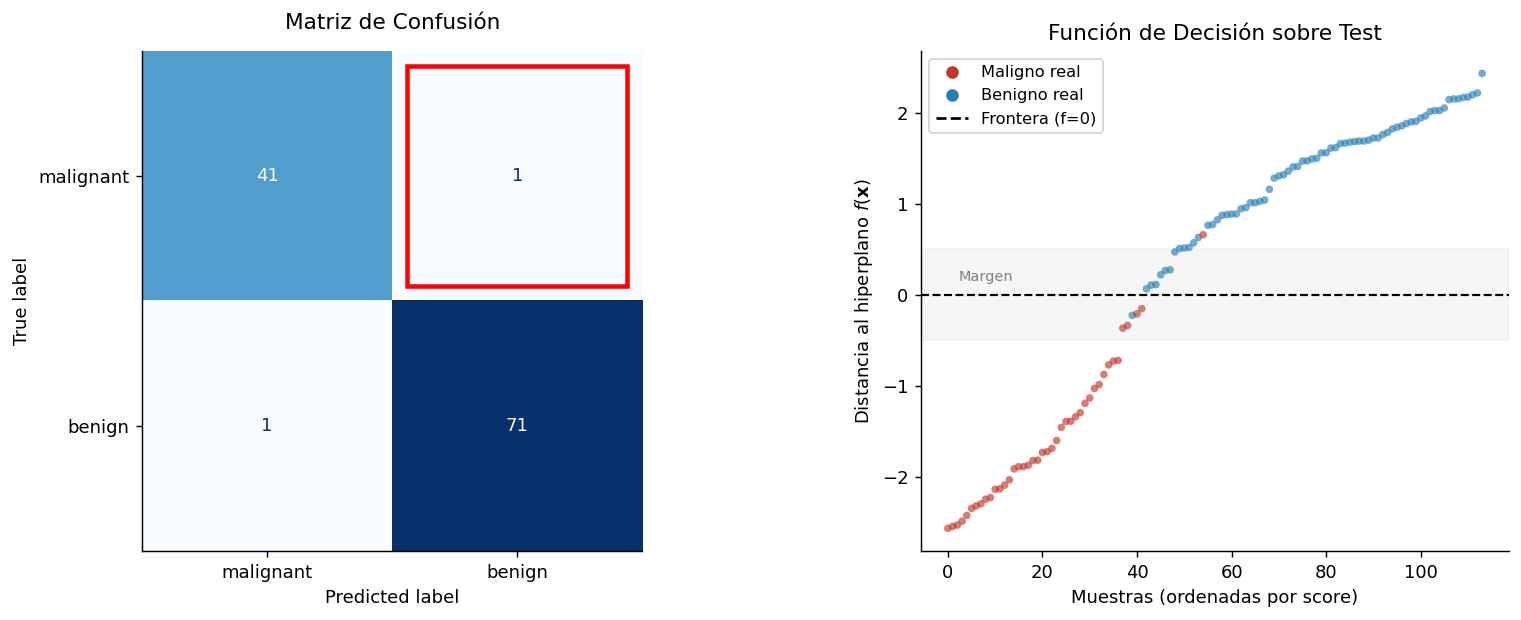

In [25]:
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.4)

# Panel izquierdo: Matriz de confusión
ax1 = fig.add_subplot(gs[0])
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=data.target_names,
    colorbar=False, ax=ax1, cmap="Blues",
)
ax1.set_title("Matriz de Confusión", fontsize=12, pad=12)

# Recuadro rojo sobre el Falso Negativo (fila 0=maligno, col 1=pred benigno)
ax1.add_patch(plt.Rectangle(
    (0.53, 0.53), 0.44, 0.44,
    fill=False, edgecolor='red', linewidth=2.5,
    transform=ax1.transAxes
))

# Panel derecho: Función de decisión
ax2 = fig.add_subplot(gs[1])
scores = model.decision_function(X_test)
orden  = np.argsort(scores)

colores = ['#c0392b' if y_test[i] == 0 else '#2980b9' for i in orden]
ax2.scatter(range(len(scores)), scores[orden],
            c=colores, alpha=0.65, s=18, edgecolors='none')
ax2.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax2.axhspan(-0.5, 0.5, alpha=0.07, color='gray')
ax2.set_xlabel("Muestras (ordenadas por score)", fontsize=10)
ax2.set_ylabel("Distancia al hiperplano $f(\\mathbf{x})$", fontsize=10)
ax2.set_title("Función de Decisión sobre Test", fontsize=12)
ax2.text(len(scores)*0.02, 0.15, "Margen", fontsize=8, color='gray')

from matplotlib.lines import Line2D
ax2.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#c0392b',
           markersize=8, label='Maligno real'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2980b9',
           markersize=8, label='Benigno real'),
    Line2D([0],[0], color='black', linestyle='--', label='Frontera (f=0)'),
], fontsize=9)

plt.savefig("svm_resultados.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Conclusiones

- De **455 muestras de entrenamiento**, solo los vectores de soporte
  (≈ 15–25%) definen la frontera — el resto fue descartado. Esto
  confirma la eficiencia de memoria característica de SVM.

- El **Recall de malignos** fue el indicador clave. Un accuracy del
  97% suena bien, pero lo que importa es cuántos tumores malignos
  reales no pasaron desapercibidos.

- El **kernel RBF** fue la elección correcta: con 30 features las
  relaciones son no lineales. El kernel proyecta implícitamente a un
  espacio de dimensión superior donde las clases sí son separables
  con un hiperplano.

- **Limitación real:** con 569 muestras el modelo entrena en
  milisegundos. En un dataset hospitalario con millones de registros,
  el costo $O(n^2)$–$O(n^3)$ de SMO haría inviable este enfoque.

---
**Referencias**
- Cortes & Vapnik (1995). *Support-vector networks*. Machine Learning, 20(3).
- Platt (1998). *Sequential Minimal Optimization*. Microsoft Research.
- Géron (2022). *Hands-On Machine Learning*, 3ra ed. O'Reilly, Cap. 5.
- Scikit-Learn: `sklearn.svm.SVC` — scikit-learn.org